# Lab 03 — Search Engineering: Package, Tests, CLI, and Benchmark

**Worked Python solution.** Labs 01–02 are refactored into `src/search_toolkit/`. This notebook validates the package, runs automated tests, exercises the CLI, and benchmarks four algorithms on ten real route queries.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "all_datasets").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the course project.")

ROOT = find_project_root()
sys.path.insert(0, str(ROOT / "src"))
print("Project root:", ROOT)

import os, subprocess
from search_toolkit import load_openflights, bfs, ucs, gbfs, astar, haversine_km

RESULTS=ROOT/"results"/"lab03"; RESULTS.mkdir(parents=True,exist_ok=True)
_,_,coords,adjacency,_=load_openflights(ROOT/"all_datasets"/"lab01-03_airports.csv",ROOT/"all_datasets"/"lab01-03_routes.csv")
queries=pd.read_csv(ROOT/"config"/"search_queries.csv")

Project root: /mnt/data/ai_course_final/ARTIFICIAL INTELLIGENCE


## 1. Automated tests

The unit tests use only small in-memory graphs, so they do not depend on Kaggle files or secrets. This is the same principle required for a GitHub Actions workflow.

In [2]:
env=os.environ.copy(); env["PYTHONPATH"]=str(ROOT/"src")
proc=subprocess.run([sys.executable,"-m","pytest","-q"],cwd=ROOT,env=env,capture_output=True,text=True,check=True)
print(proc.stdout)

.......                                                                  [100%]
7 passed in 0.06s



## 2. Command-line interface

In [3]:
cli=subprocess.run([sys.executable,"-m","search_toolkit","--algorithm","astar","--start","KUL","--goal","KEF"],
                   cwd=ROOT,env=env,capture_output=True,text=True,check=True)
print(cli.stdout)

ASTAR: found=True, hops=4, cost_km=11461.3, expanded=70, runtime_ms=1.02
KUL -> HKT -> LED -> HEL -> KEF



## 3. Ten-query benchmark

In [4]:
rows=[]
for q in queries.itertuples(index=False):
    h=lambda n,goal=q.goal:haversine_km(coords[n]["latitude"],coords[n]["longitude"],coords[goal]["latitude"],coords[goal]["longitude"])
    methods={"BFS":lambda:bfs(adjacency,q.start,q.goal),
             "UCS":lambda:ucs(adjacency,q.start,q.goal),
             "GBFS":lambda:gbfs(adjacency,q.start,q.goal,h),
             "A*":lambda:astar(adjacency,q.start,q.goal,h)}
    for name,fn in methods.items():
        r=fn(); rows.append({"query_id":q.query_id,"algorithm":name,"success":r.found,
                             "cost_km":r.path_cost_km,"hops":r.hops,"expanded":r.expanded,
                             "runtime_ms":r.runtime_ms})
bench=pd.DataFrame(rows); bench.to_csv(RESULTS/"benchmark.csv",index=False)
summary=bench.groupby("algorithm").agg(success_rate=("success","mean"),
    mean_cost_km=("cost_km","mean"),median_expanded=("expanded","median"),
    mean_expanded=("expanded","mean"),median_runtime_ms=("runtime_ms","median")).round(2)
summary.to_csv(RESULTS/"benchmark_summary.csv")
summary

,success_rate,mean_cost_km,median_expanded,mean_expanded,median_runtime_ms
algorithm,,,,,
A*,1.0,12829.16,12.5,62.1,0.70
BFS,1.0,14239.15,4.0,7.7,3.97
GBFS,1.0,13038.71,3.0,3.1,0.39
UCS,1.0,12829.16,2497.5,2496.7,7.16


A* cost equals UCS for all 10 queries: True
GBFS is costlier than UCS on 4 queries.


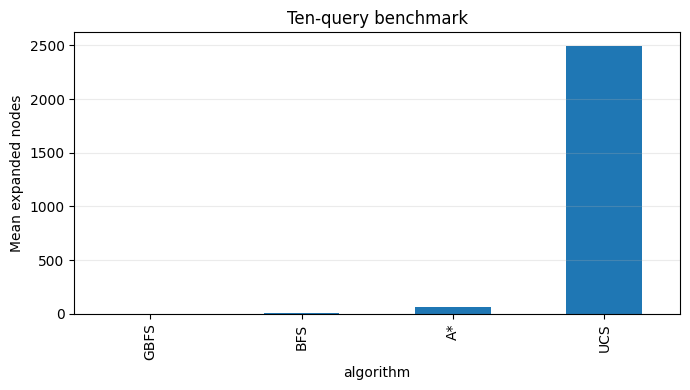

In [5]:
p=bench.pivot(index="query_id",columns="algorithm",values="cost_km")
print("A* cost equals UCS for all 10 queries:", np.allclose(p["A*"],p["UCS"]))
print("GBFS is costlier than UCS on",int((p["GBFS"]>p["UCS"]+1e-6).sum()),"queries.")

ax=summary[["mean_expanded"]].sort_values("mean_expanded").plot(kind="bar",legend=False,figsize=(7,4))
ax.set_ylabel("Mean expanded nodes"); ax.set_title("Ten-query benchmark")
ax.grid(axis="y",alpha=.25); plt.tight_layout(); plt.savefig(RESULTS/"benchmark_expansions.png",dpi=160); plt.show()

## Worked engineering answer

The package boundary is now clear: `core.py` contains generic search algorithms; `openflights.py` owns dataset-specific loading and distance logic; `__main__.py` is only a user interface. The tests cover start=goal, unreachable states, cycles, weighted shortest paths, frontier updates, A* consistency with UCS, and invalid negative costs.

On the real benchmark, **A*** is the best default when route distance is the objective: it preserves UCS cost while using a fraction of the expansions. **BFS** is useful only when hop count is the intended objective, and **GBFS** is an approximate speed-oriented alternative.

A professional repository should keep these unit tests independent of Kaggle data so CI can run on every push.

### Suggested GitHub evidence
1. push `src/`, `tests/`, notebooks, and small configuration files;
2. run `pytest -q` locally before pushing;
3. create a GitHub Actions workflow that runs the same command;
4. tag the accepted state as `lab03-final`.